1**. Introduction**

House prices depend on many things such as area, number of rooms, and facilities. Because of this, it is not easy to predict house prices manually.

In this project, machine learning regression models are used to predict house prices based on past data. The model learns from previous housing prices and uses that knowledge to predict new prices.

2. **Problem Statement**

The aim of this project is to predict the price of a house using its features like area, bedrooms, bathrooms, and other facilities.

This is a supervised learning problem, where the model is trained using known house prices and then tested on new data.

**3. Methodology**

The project is completed using the following steps:

1,Load the housing dataset

2,Check and understand the data

3,Convert text data (Yes/No) into numbers

4,Scale the data for better learning

5,Split the data into training and testing sets

6,Train regression models

7,Test the models on new data

8,Measure accuracy using evaluation metrics1,

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error


In [45]:
from google.colab import files
uploaded = files.upload()


Saving Housing Price.csv to Housing Price (1).csv


In [46]:
df = pd.read_csv("Housing Price.csv")
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [47]:
df.isnull().sum()


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


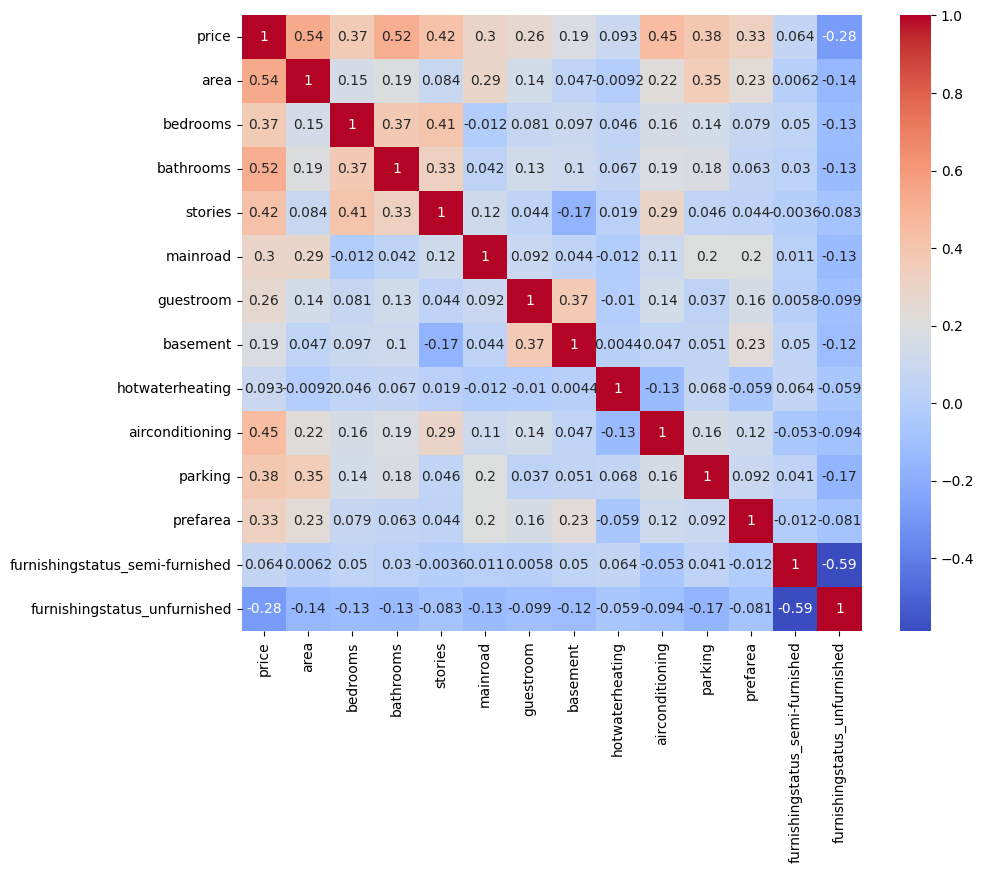

In [48]:
df_encoded = df.copy()


binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})

df_encoded = pd.get_dummies(df_encoded, columns=['furnishingstatus'], drop_first=True)

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.show()

In [49]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

df[binary_cols] = df[binary_cols].applymap(lambda x: 1 if x == 'yes' else 0)

/tmp/ipython-input-1623039534.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[binary_cols] = df[binary_cols].applymap(lambda x: 1 if x == 'yes' else 0)


In [50]:
le = LabelEncoder()
df['furnishingstatus'] = le.fit_transform(df['furnishingstatus'])

In [51]:
X = df.drop('price', axis=1) # Separate features from the target variable
y = df['price'] # Target variable

# Identify categorical columns (object type) for one-hot encoding.
# These typically include binary 'yes'/'no' columns and 'furnishingstatus'.
categorical_cols = X.select_dtypes(include=['object']).columns

# Apply one-hot encoding to convert categorical features into numerical ones.
# `drop_first=True` helps prevent multicollinearity by dropping one redundant category column
if not categorical_cols.empty:
    print(f"Applying one-hot encoding to categorical columns: {list(categorical_cols)}")
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Identify columns with zero standard deviation (constant columns).
# These columns provide no predictive power and can cause issues with some models/scalers.
constant_columns = X.columns[X.std() == 0]

# Drop constant columns from X if any are found
if not constant_columns.empty:
    print(f"Dropping constant columns: {list(constant_columns)}")
    X = X.drop(columns=constant_columns)

# Crucial check: Ensure the feature matrix is not empty after preprocessing
if X.empty:
    raise ValueError("X is empty after preprocessing. Check previous steps.")

# Initialize and apply StandardScaler to scale numerical features.
# Scaling is important for models sensitive to feature magnitudes, like KNN and some linear models.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the processed data into training and testing sets.
# test_size=0.2 means 20% of data for testing, random_state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [52]:
# Train a Multiple Linear Regression model.
# This model uses all processed and scaled features to predict house prices.
multi_linear_model = LinearRegression()
multi_linear_model.fit(X_train, y_train)

# Make predictions on the test set using the multiple linear regression model.
y_pred_multi = multi_linear_model.predict(X_test)

# Evaluate the Multiple Linear Regression model's performance.
r2_multi = r2_score(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
mape_multi = mean_absolute_percentage_error(y_test, y_pred_multi)

print(f"Multiple Linear Regression R2 Score: {r2_multi:.4f}")
print(f"Multiple Linear Regression Mean Squared Error: {mse_multi:.2f}")
print(f"Multiple Linear Regression Mean Absolute Percentage Error: {mape_multi:.4f}")

Multiple Linear Regression R2 Score: 0.6495
Multiple Linear Regression Mean Squared Error: 1771751116594.04
Multiple Linear Regression Mean Absolute Percentage Error: 0.2131


In [53]:
# Train a Simple Linear Regression model using only the 'area' feature.
X_area = df[['area']] # Select only the 'area' feature from the DataFrame
y = df['price']       # Target variable (price)

# Split the 'area' feature and target into training and testing sets.
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_area, y, test_size=0.2, random_state=42
)

# Initialize and train the Simple Linear Regression model.
lr_simple = LinearRegression()
lr_simple.fit(X_train_a, y_train_a)

# Make predictions on the test set using the simple linear model.
y_pred_simple = lr_simple.predict(X_test_a)

In [54]:
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
y_pred_multi = lr_multi.predict(X_test)


In [55]:
# Initialize PolynomialFeatures to create polynomial terms (degree 2).
# This adds non-linear relationships between features for the model.
poly = PolynomialFeatures(degree=2)

# Transform the training features (X_train) into polynomial features.
X_poly = poly.fit_transform(X_train)

# Train a Linear Regression model on the polynomial features.
lr_poly = LinearRegression()
lr_poly.fit(X_poly, y_train)

# Transform the test features (X_test) using the *same* polynomial transformation fitted on training data.
X_test_poly = poly.transform(X_test)

# Make predictions on the transformed test set.
y_pred_poly = lr_poly.predict(X_test_poly)

In [56]:
# Initialize a K-Nearest Neighbors Regressor with 5 neighbors.
knn = KNeighborsRegressor(n_neighbors=5)

# Train the KNN model on the scaled training data.
knn.fit(X_train, y_train)

# Make predictions on the test set using the KNN model.
y_pred_knn = knn.predict(X_test)

In [57]:
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return r2, rmse, mape


In [58]:
# Dictionary to store predictions from different models for summary evaluation.
models = {
    "Simple Linear": y_pred_simple,   # Predictions from the Simple Linear Regression model
    "Multiple Linear": y_pred_multi,  # Predictions from the Multiple Linear Regression model
    "Polynomial": y_pred_poly,        # Predictions from the Polynomial Regression model
    "KNN": y_pred_knn                 # Predictions from the K-Nearest Neighbors Regression model
}

# Loop through each model's predictions and evaluate its performance.
for name, preds in models.items():
    # Calculate R2 score, RMSE, and MAPE using the helper function `evaluate_model`.
    r2, rmse, mape = evaluate_model(y_test, preds)
    # Print the evaluation metrics for each model.
    print(f"{name} -> R2: {r2:.3f}, RMSE: {rmse:.2f}, MAPE: {mape:.2%}")

Simple Linear -> R2: 0.273, RMSE: 1917103.70, MAPE: 32.28%
Multiple Linear -> R2: 0.649, RMSE: 1331071.42, MAPE: 21.31%
Polynomial -> R2: 0.652, RMSE: 1326941.74, MAPE: 21.59%
KNN -> R2: 0.574, RMSE: 1466725.14, MAPE: 21.66%


In [59]:
# Code to check the shape and head of the preprocessed and split data
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nHead of X_train (first 5 rows):\n", pd.DataFrame(X_train).head())
print("\nHead of y_train (first 5 rows):\n", y_train.head())

Shape of X_train: (436, 12)
Shape of X_test: (109, 12)
Shape of y_train: (436,)
Shape of y_test: (109,)

Head of X_train (first 5 rows):
          0         1         2         3         4         5         6   \
0  0.391790  0.047278  1.421812  2.532024  0.405623 -0.465315 -0.734539   
1  0.945257  0.047278  1.421812 -0.929397  0.405623 -0.465315  1.361397   
2 -0.615521 -1.308863 -0.570187 -0.929397  0.405623 -0.465315  1.361397   
3 -1.171756  0.047278 -0.570187  0.224410  0.405623 -0.465315  1.361397   
4 -0.645962  0.047278 -0.570187  0.224410  0.405623 -0.465315 -0.734539   

         7         8         9         10        11  
0 -0.219265  1.472618  0.355976 -0.554035 -1.406286  
1 -0.219265  1.472618  2.679409 -0.554035 -0.091662  
2 -0.219265  1.472618  1.517692 -0.554035 -1.406286  
3 -0.219265 -0.679063 -0.805741  1.804941  1.222962  
4 -0.219265 -0.679063 -0.805741 -0.554035  1.222962  

Head of y_train (first 5 rows):
 46     7525000
93     6300000
335    3920000
412    3

**Conclusion**


This project applied different regression models to predict house prices. Multiple linear regression and polynomial regression performed better than simple linear regression.

